# Analysis of `2nd Order SHAP` Values

## Purpose: 
* Get `SHAP` metrics
* Interaction triangular heatmaps
* `PPI` ROC/PR curves
* `PPI` and `PPI Types` distribution comparison
* Importance networks and positional activity
* Most important interactions per cell line
* Most similar interactions between cell lines
* `Signed` behavior at position combinations
* Deeper dive into validating strong and opposing `main` vs `interaction` effects
* Create screening table to systematically look at interactions with `Actual PSI` changes

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Config + Load Analysis Class</h1>

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import polars as pl 
_=pl.Config.set_tbl_cols(1000000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)


%load_ext autoreload 
%autoreload 2

import importlib

SecondOrderShapNetworkAnalyzer = getattr(
    importlib.import_module("2_second_order_shap_analysis"), 
    "SecondOrderShapNetworkAnalyzer"
)

analyzer = SecondOrderShapNetworkAnalyzer()

import yaml 

with open('./1_variable_config.yaml', 'r') as file:
    CONFIG = yaml.safe_load(file)


2026-05-02 21:24:37.598 | SUCCESS  | 2_second_order_shap_analysis:__post_init__:36 - Class initialized and loaded.


<h1 style="color: teal; font-weight: bold; font-size: 48px;">Retrieve SHAP Metrics</h1>

In [ ]:
example = analyzer.retrieve_shap_values_for_metric(metric = "Signed-Local-SHAP-Mean-Bound-Only")
example.sample(20)

In [ ]:
analyzer.compare_importance_vs_directionality()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Interaction Heatmaps</h1>

In [ ]:
for source in CONFIG["PPI_SOURCES"]: 
    for highlight in CONFIG["PPI_TYPES"]: 
    
        HepG2_options = {
            "highlight": highlight,
            
            "figsize": (22, 10),
            'dpi': 600,
            'tick_fontsize': 2, 
            'title_fontsize': 20, 
            'cell_linewidth': 0.05, 
            'legend_titlesize': 15, 
            'label_padding': 5
        }
        
        analyzer.plot_side_by_side_heatmaps_for_min_1_ppi(
            cell_line = "HepG2", 
            ppi_source= source, 
            metric = 'Signed-Local-SHAP-Mean-Bound-Only',
            **HepG2_options
        )

In [ ]:
for source in CONFIG["PPI_SOURCES"]: 
    for highlight in CONFIG["PPI_TYPES"]: 
    
        K562_options = {
            "highlight": highlight,
            
            "figsize": (24, 11),
            'dpi': 600,
            'tick_fontsize': 1.5, 
            'title_fontsize': 20, 
            'cell_linewidth': 0.02, 
            'legend_titlesize': 15, 
            'label_padding': 5
        }
        
        analyzer.plot_side_by_side_heatmaps_for_min_1_ppi(
            cell_line = "K562", 
            ppi_source= source, 
            metric = 'Signed-Local-SHAP-Mean-Bound-Only',
            **K562_options
        )

<h1 style="color: teal; font-weight: bold; font-size: 48px;">PPI ROC/PR Curves</h1>

# Signed Bound Mean (Directionality)

### Supplementary Figure w/ All Curves

In [ ]:
analyzer.plot_all_roc_and_pr_curve_combinations_for_rbp_specific_max_value(metric="Signed-Local-SHAP-Mean-Bound-Only")

### Main Figure w/ Selected Curves

In [ ]:
analyzer.plot_selected_roc_and_pr_curves_for_main_figure(metric="Signed-Local-SHAP-Mean-Bound-Only")

# Bound Only (Importance)

### Supplementary Figure w/ All Curves

2026-05-02 21:24:41.917 | SUCCESS  | 2_second_order_shap_analysis:retrieve_shap_values_for_metric:715 - FROM CACHE: loading 'Bound-Only' values from '../outputs/SHAP_cache/averages/Bound-Only.tsv'...
2026-05-02 21:24:42.068 | INFO     | 2_second_order_shap_analysis:calculate_roc_and_pr_curve_data_for_metric:1596 - # points: 6554, Plot Type: FEATURE-SPECIFIC, Cell line: HepG2, PPI source: Rec-Y2H, PPI type: Same-Position
2026-05-02 21:24:42.110 | INFO     | 2_second_order_shap_analysis:calculate_roc_and_pr_curve_data_for_metric:1596 - # points: 30988, Plot Type: FEATURE-SPECIFIC, Cell line: HepG2, PPI source: Rec-Y2H, PPI type: Different-Position
2026-05-02 21:24:42.168 | INFO     | 2_second_order_shap_analysis:calculate_roc_and_pr_curve_data_for_metric:1596 - # points: 37542, Plot Type: FEATURE-SPECIFIC, Cell line: HepG2, PPI source: Rec-Y2H, PPI type: All-Positions
2026-05-02 21:24:42.219 | INFO     | 2_second_order_shap_analysis:calculate_roc_and_pr_curve_data_for_metric:1596 - # poi

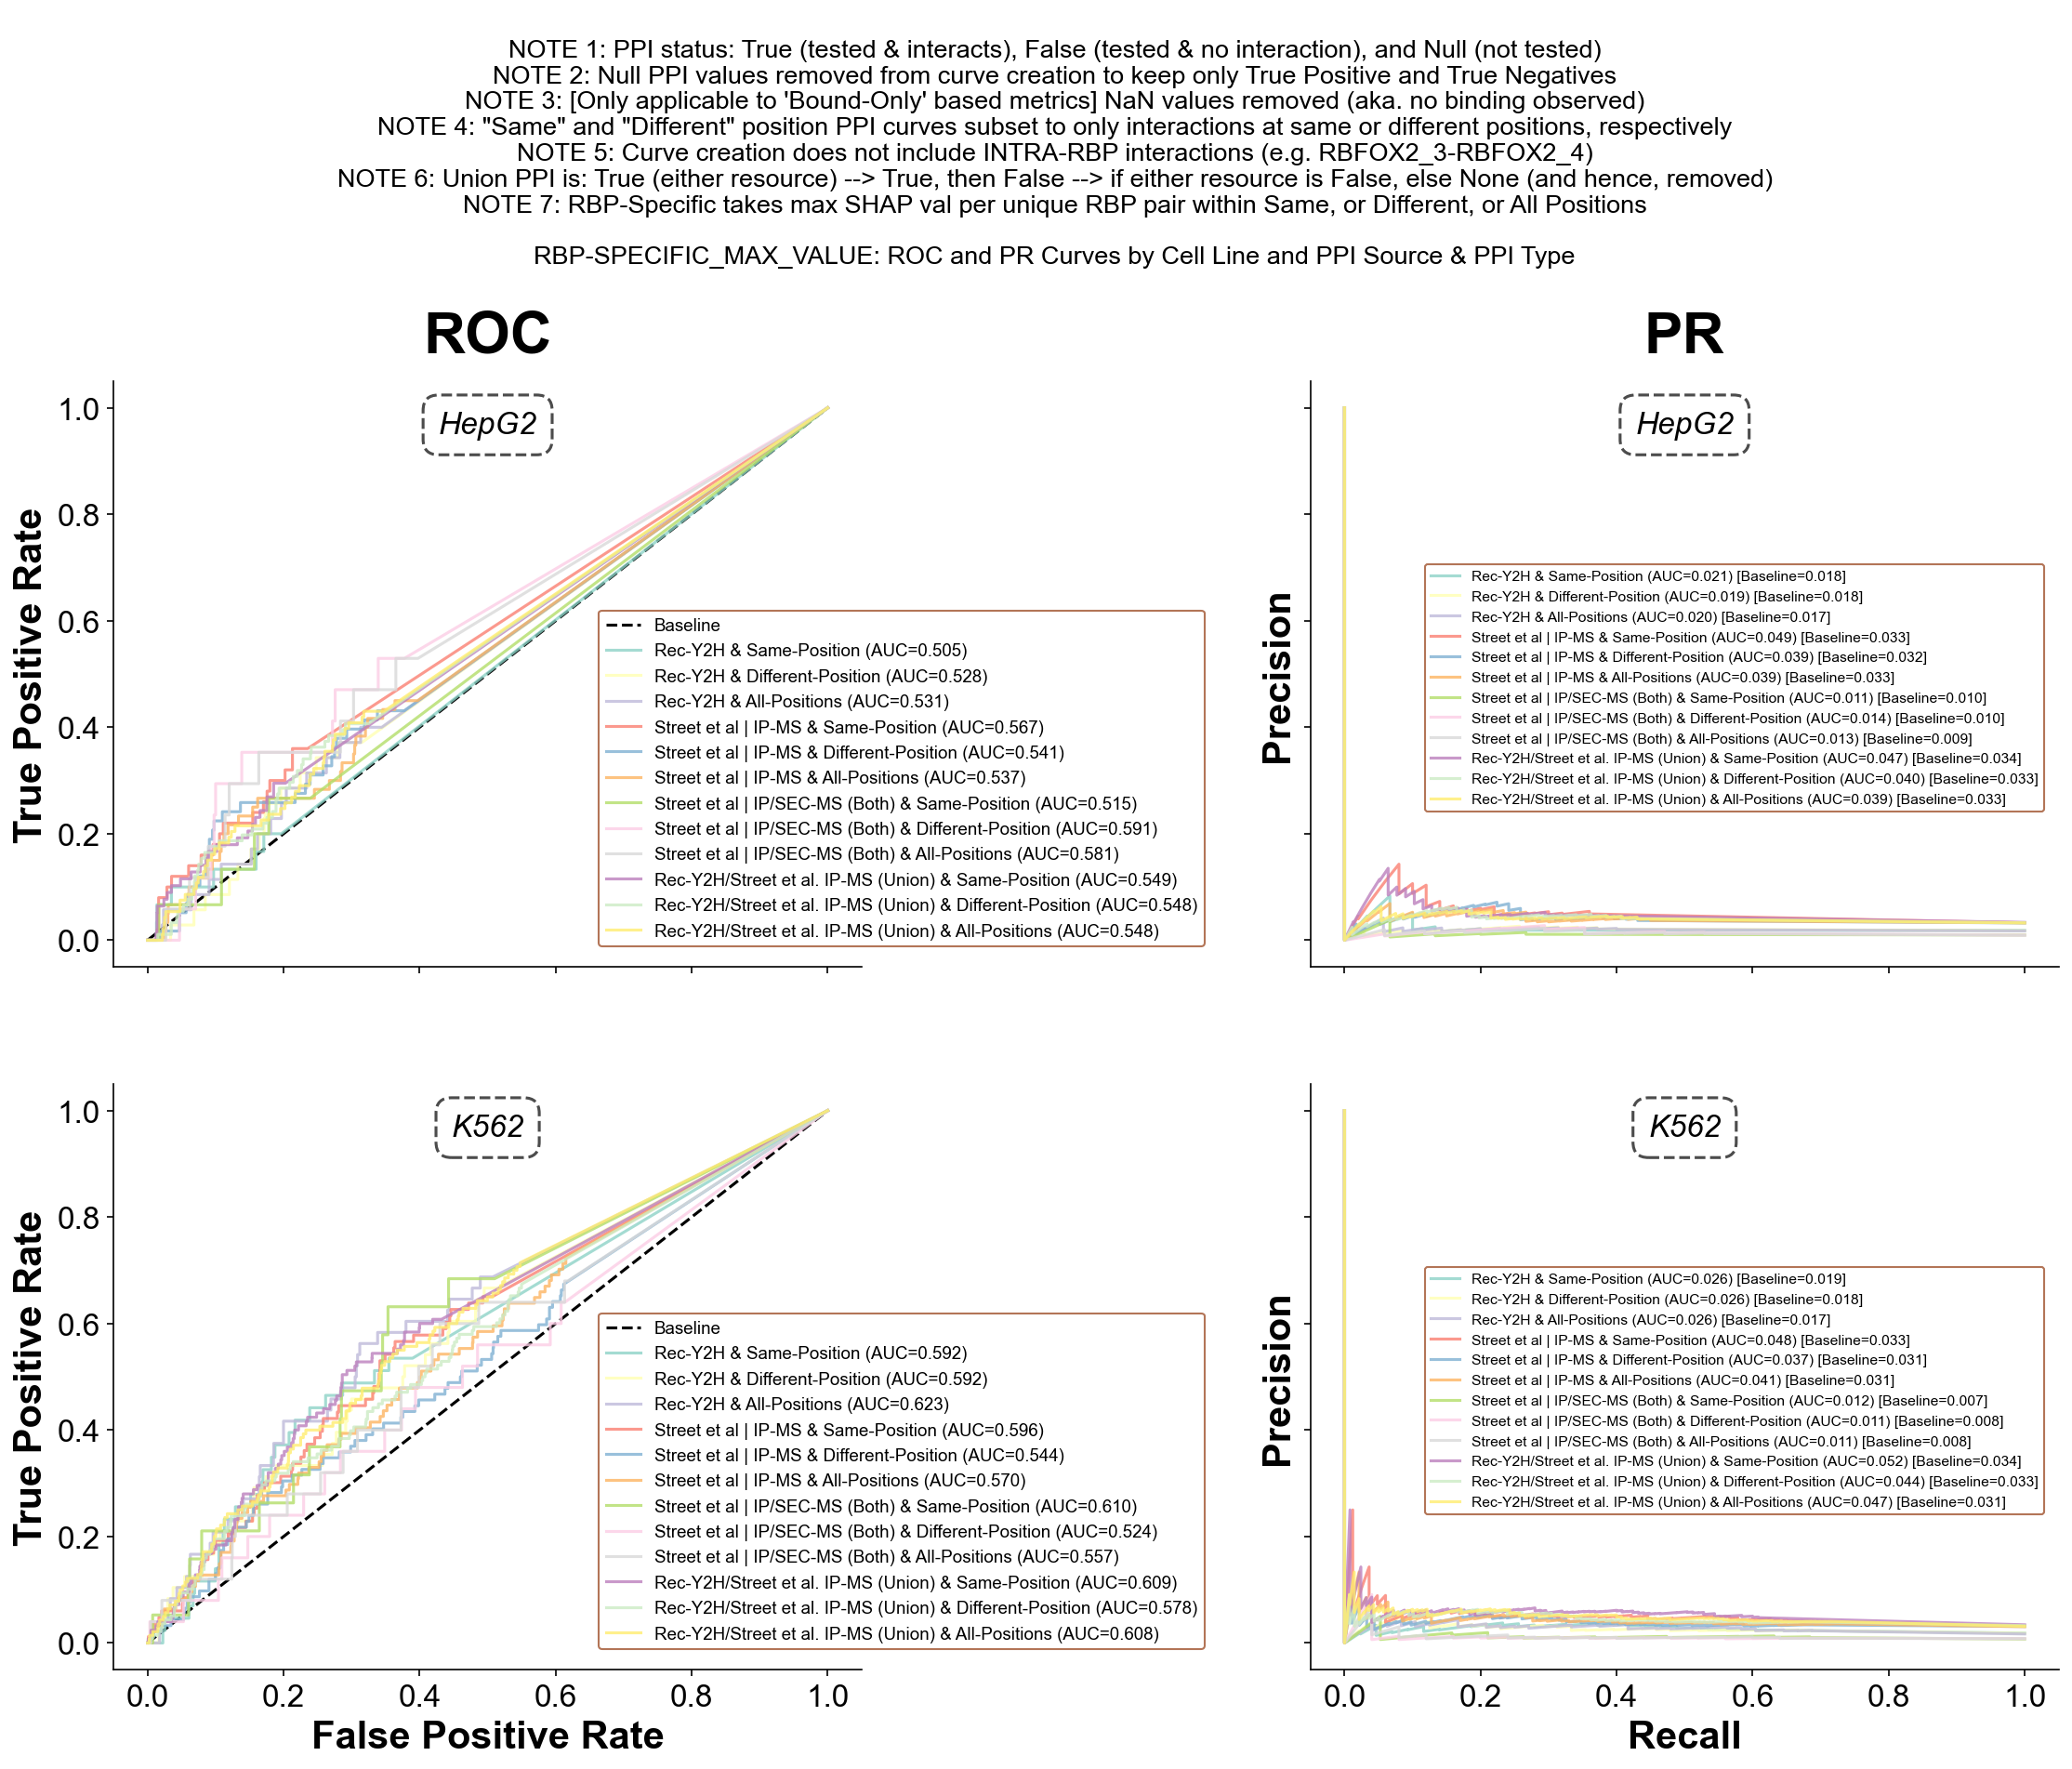

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_second_order_SHAP_analysis/2_analyze_shap_interaction_values/code/2_second_order_shap_analysis.py:1778: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


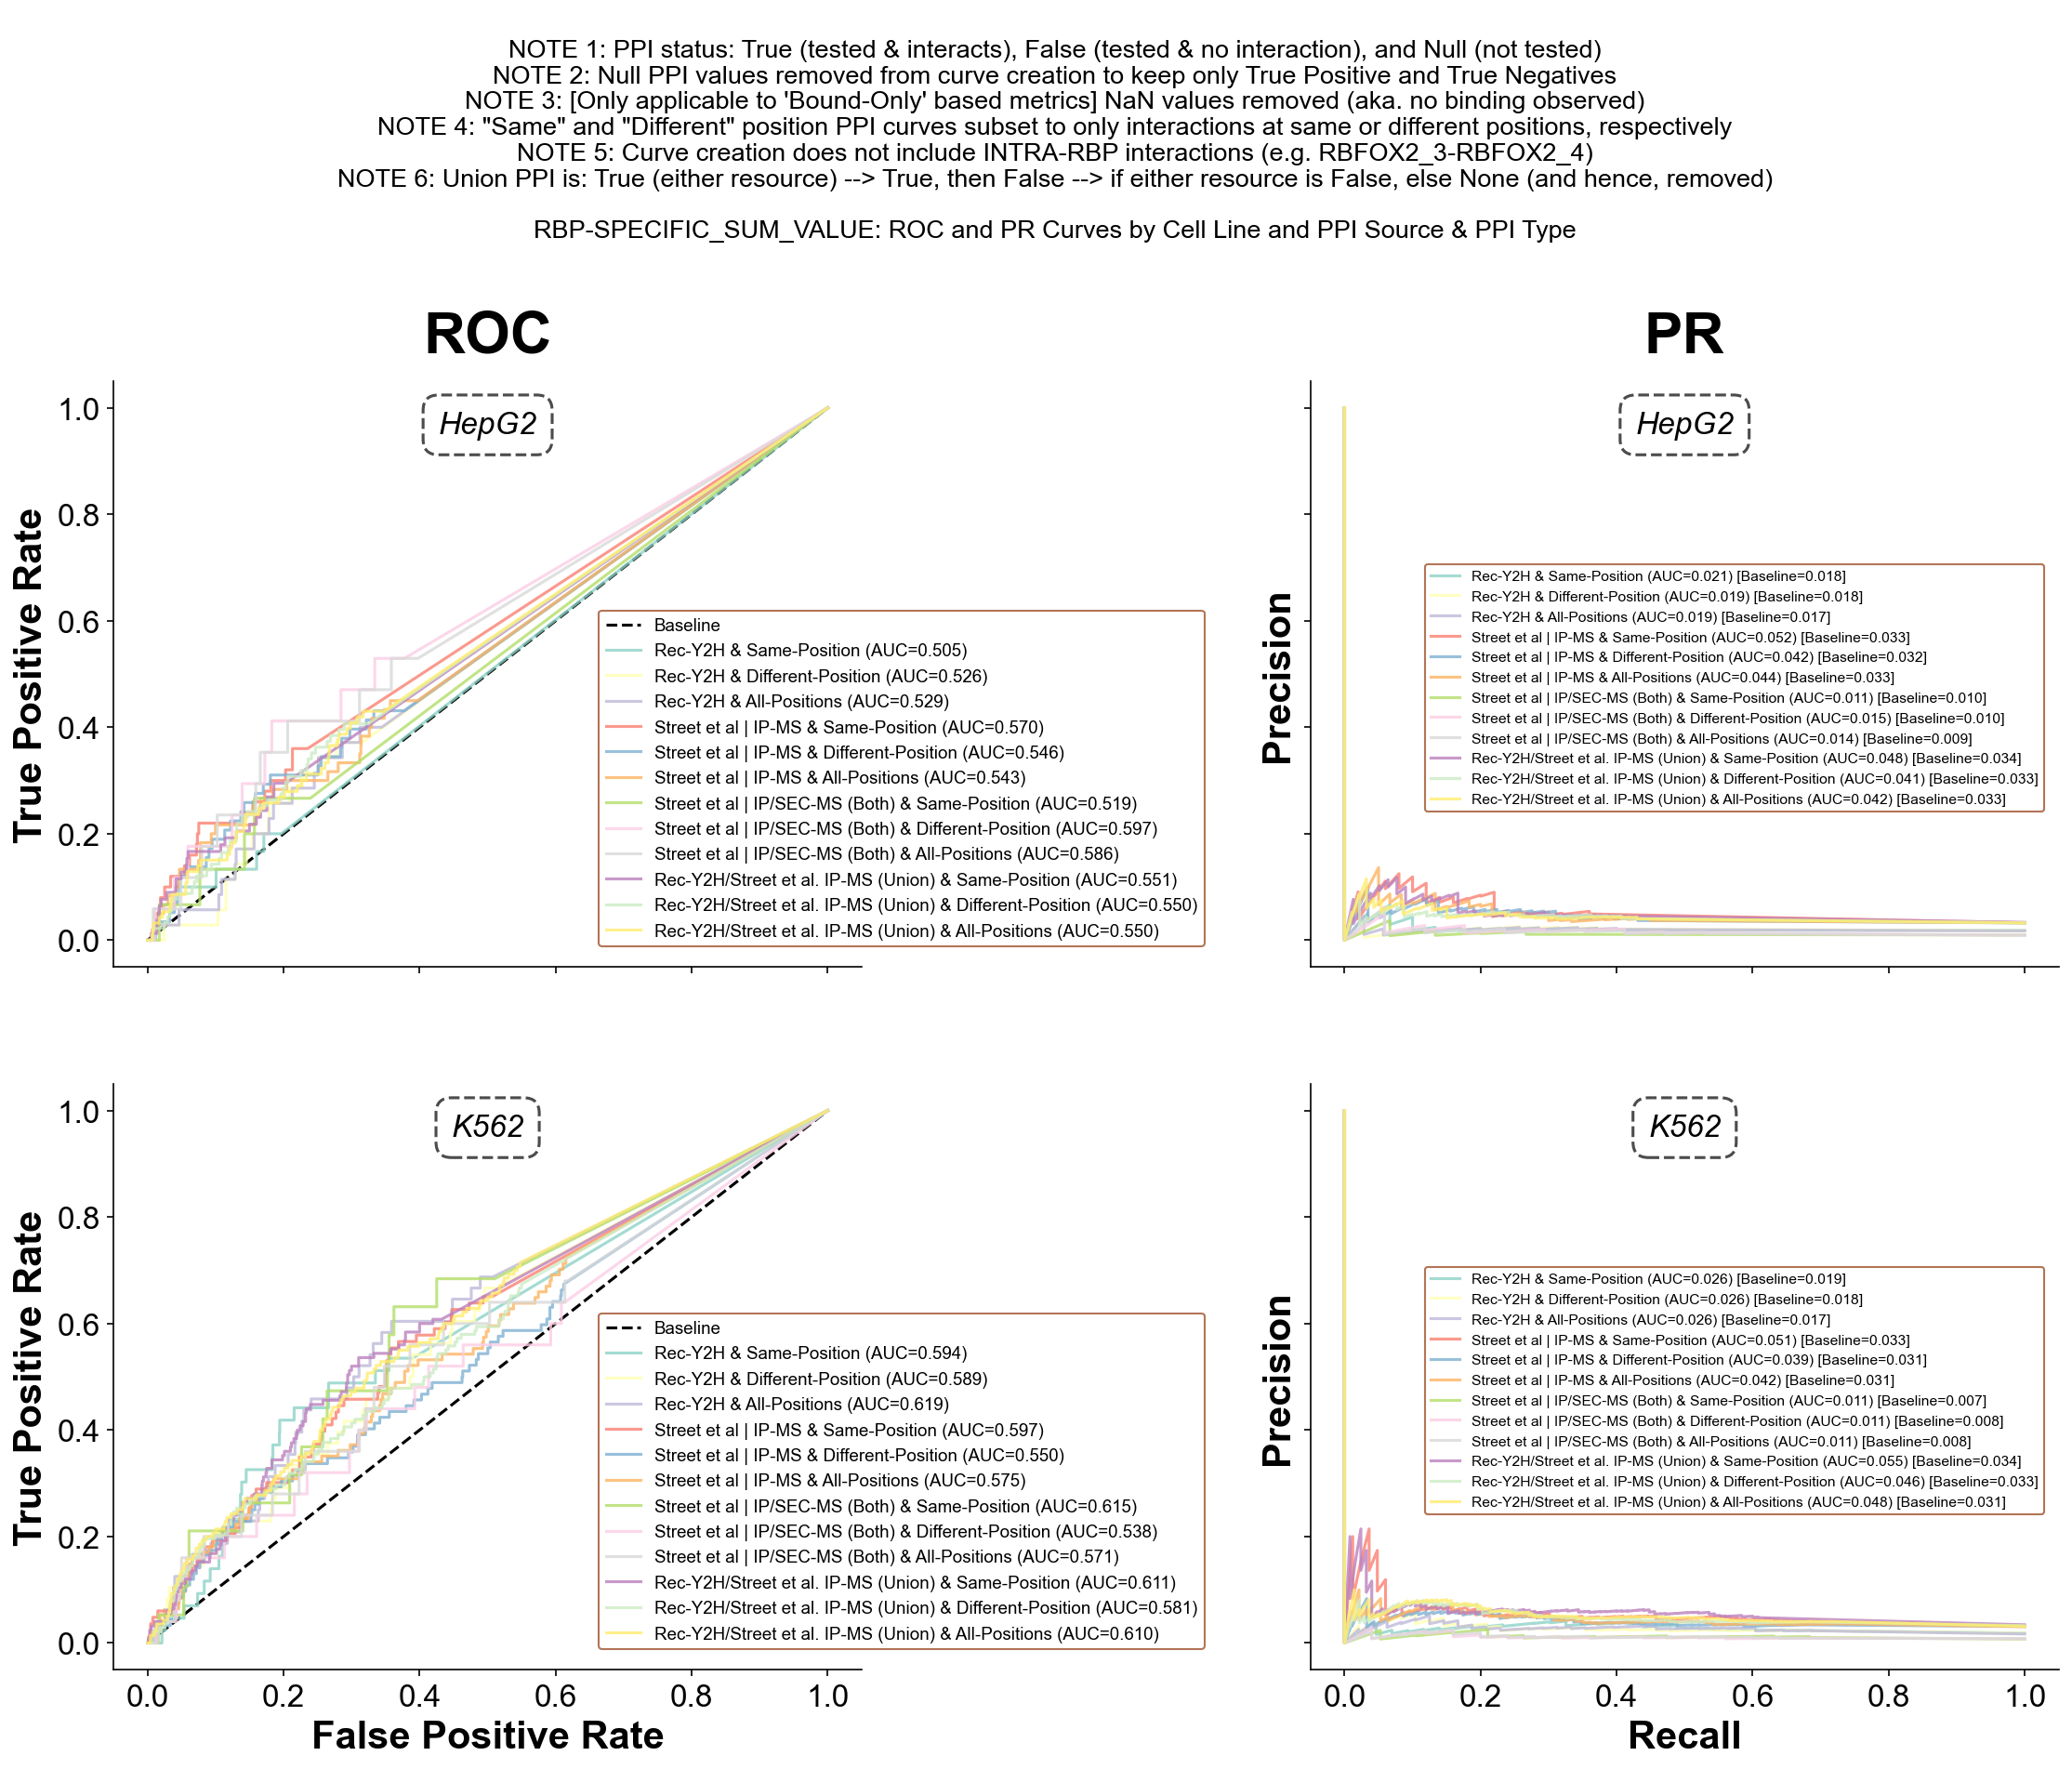

In [2]:
analyzer.plot_all_roc_and_pr_curve_combinations_for_rbp_specific_max_value(metric="Bound-Only")

### Main Figure w/ Selected Curves

2026-05-02 21:25:17.993 | SUCCESS  | 2_second_order_shap_analysis:retrieve_shap_values_for_metric:715 - FROM CACHE: loading 'Bound-Only' values from '../outputs/SHAP_cache/averages/Bound-Only.tsv'...
2026-05-02 21:25:18.087 | INFO     | 2_second_order_shap_analysis:calculate_roc_and_pr_curve_data_for_metric:1596 - # points: 6554, Plot Type: FEATURE-SPECIFIC, Cell line: HepG2, PPI source: Rec-Y2H, PPI type: Same-Position
2026-05-02 21:25:18.124 | INFO     | 2_second_order_shap_analysis:calculate_roc_and_pr_curve_data_for_metric:1596 - # points: 30988, Plot Type: FEATURE-SPECIFIC, Cell line: HepG2, PPI source: Rec-Y2H, PPI type: Different-Position
2026-05-02 21:25:18.180 | INFO     | 2_second_order_shap_analysis:calculate_roc_and_pr_curve_data_for_metric:1596 - # points: 37542, Plot Type: FEATURE-SPECIFIC, Cell line: HepG2, PPI source: Rec-Y2H, PPI type: All-Positions
2026-05-02 21:25:18.233 | INFO     | 2_second_order_shap_analysis:calculate_roc_and_pr_curve_data_for_metric:1596 - # poi

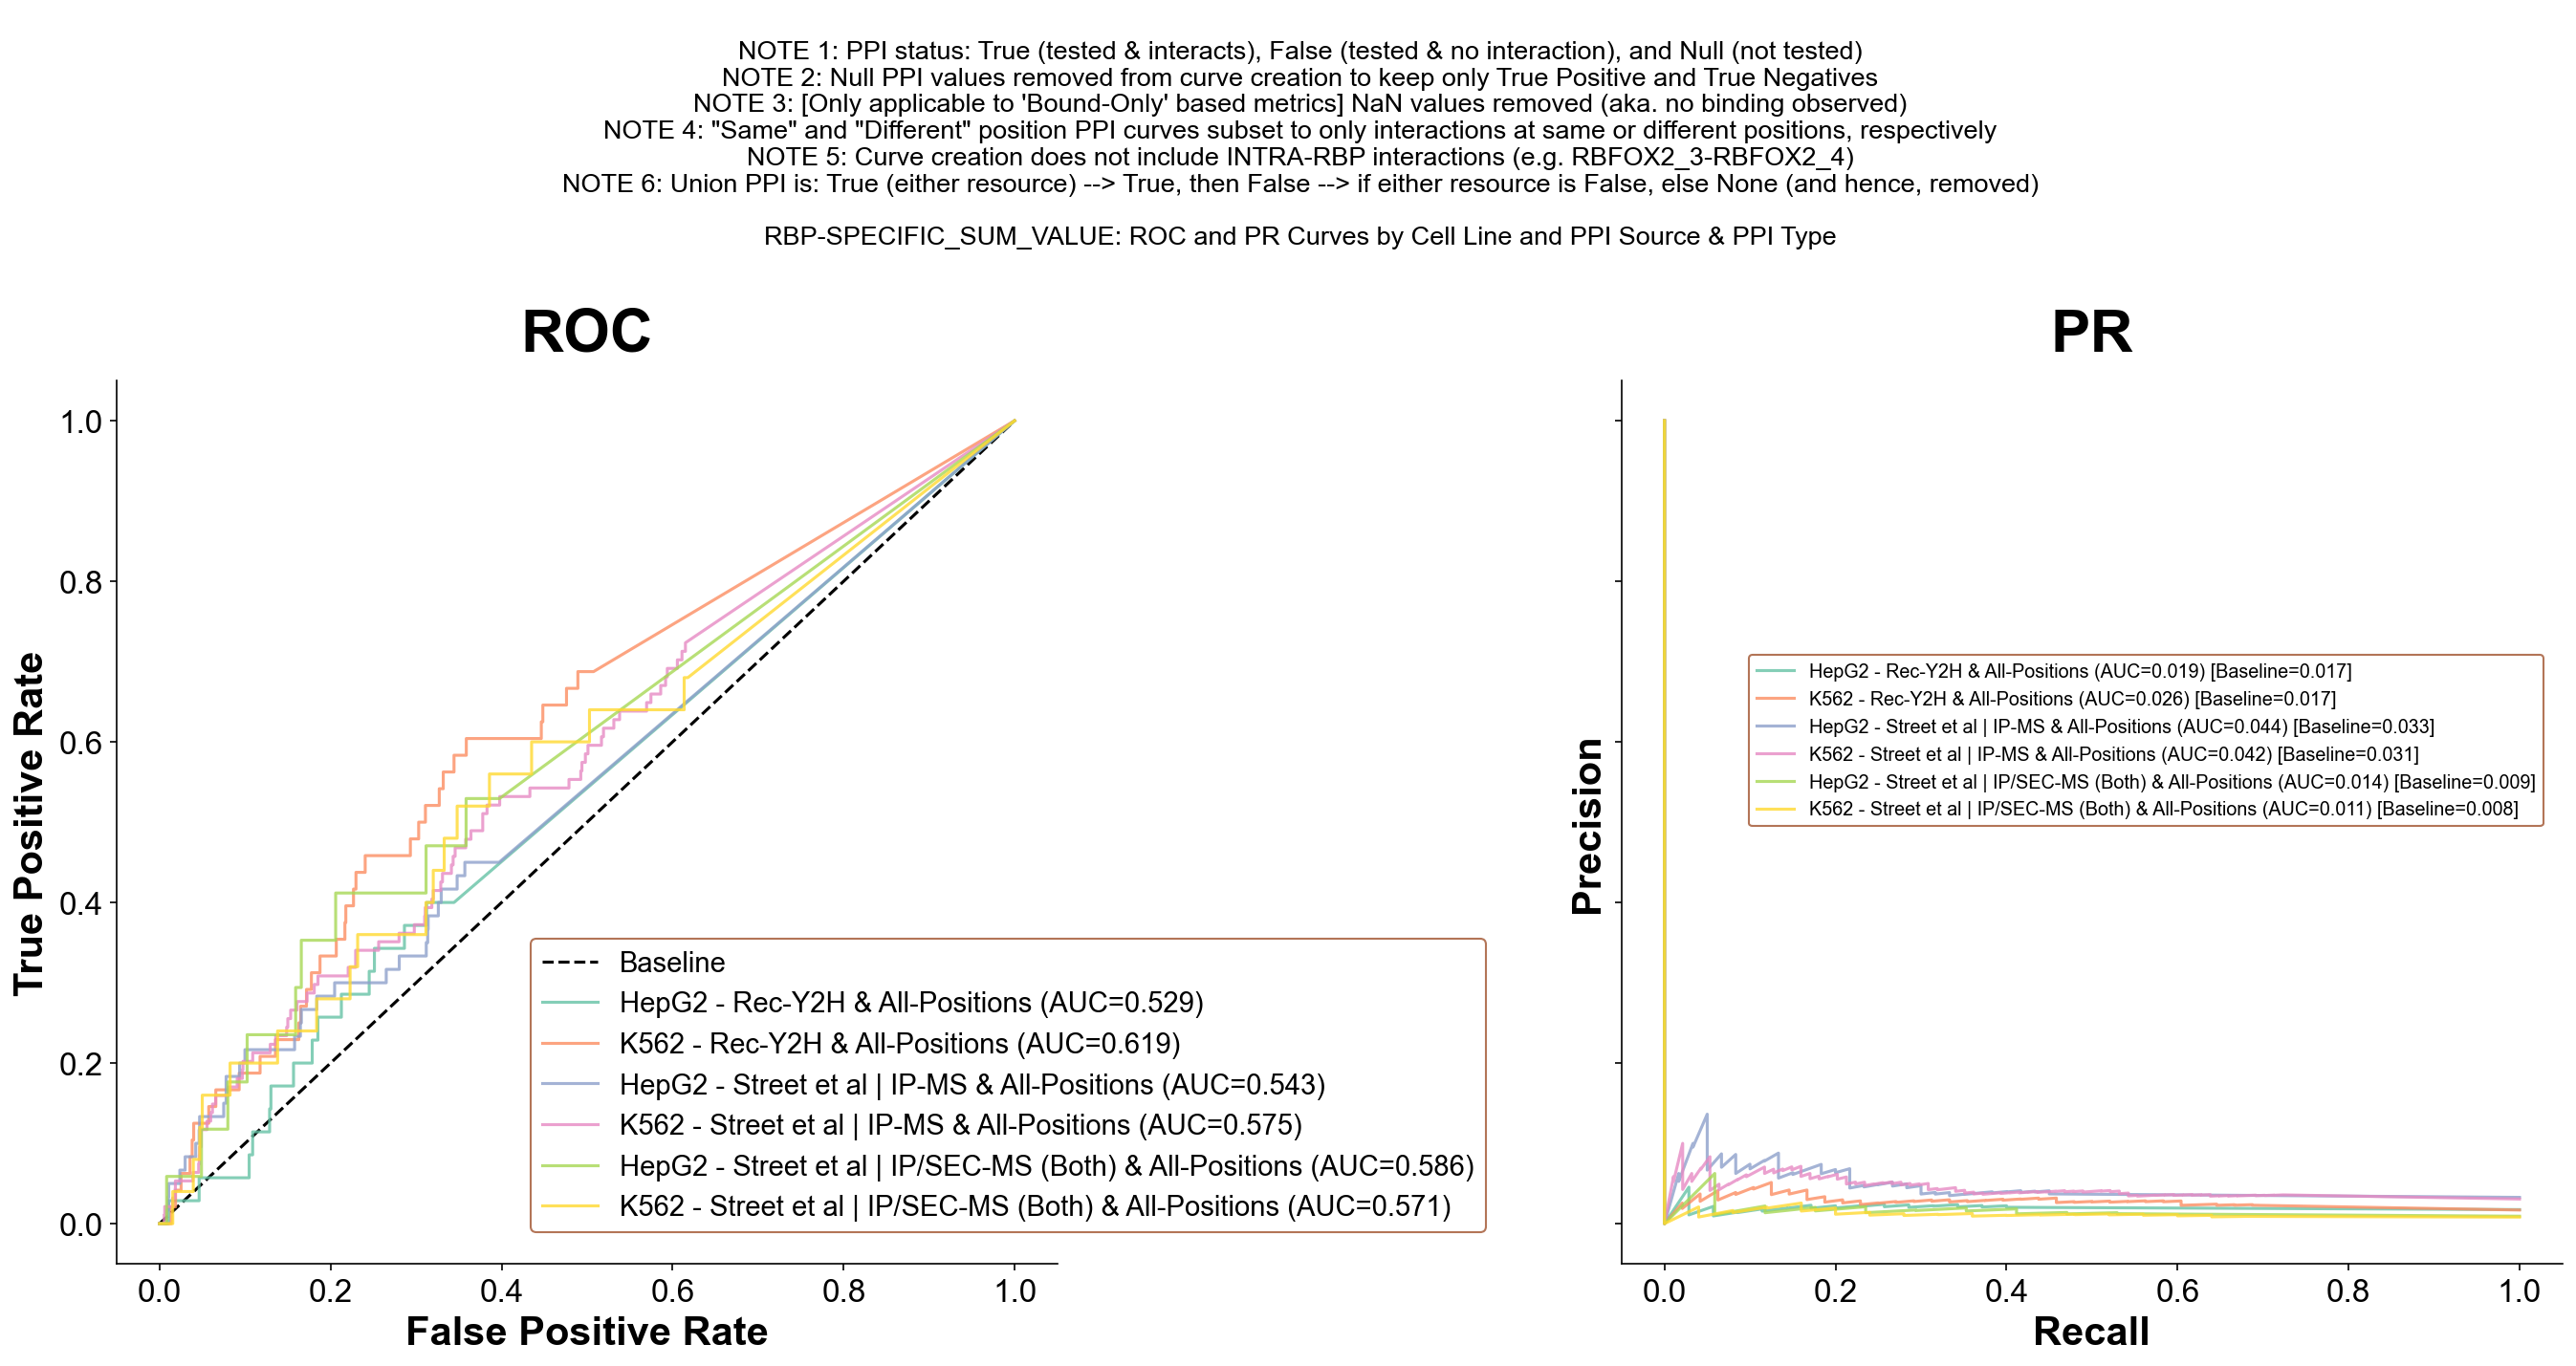

In [3]:
analyzer.plot_selected_roc_and_pr_curves_for_main_figure(metric="Bound-Only")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Actual PSI by Binding for All Position PPI-Only Interactions</h1>

## No need to run below as no longer relevant

In [ ]:
# analyzer.plot_actual_psi_by_binding_for_PPI()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Distributions of PPI/Non-PPI Values</h1>

In [ ]:
analyzer.ppi_vs_non_ppi_shap_value_distributions(metric = "Signed-Local-SHAP-Mean-Bound-Only")

In [ ]:
analyzer.ppi_type_shap_value_distributions(metric = "Signed-Local-SHAP-Mean-Bound-Only")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Interaction Importance Networks</h1>

In [ ]:
importance_network_info = analyzer.retrieve_importance_network()

In [ ]:
analyzer.plot_edge_weights_per_position()

In [ ]:
analyzer.plot_average_importance_between_positions()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Top Interactions & Cell Line Interaction Similarity</h1>

In [ ]:
analyzer.top_interactions_per_cell_line()

In [ ]:
analyzer.plot_interaction_cell_line_similarity_scatterplot(label_top_points = 30)

In [ ]:
analyzer.create_top_cell_line_average_interactions_barplot()

In [ ]:
analyzer.plot_interaction_sign_concordance_over_shap_thresholds()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Signed Version of Positional Behavior</h1>

In [ ]:
analyzer.plot_position_combination_directionality()

In [ ]:
analyzer.retrieve_cell_line_concordant_interaction_values_for_rbp_prefix(
    rbp_prefix="RBM", 
    position1=3, 
    position2=4
)

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Investigation/Validation of Strong Opposing Main vs Interaction Effects

In [ ]:
analyzer.validate_selected_interactions_actual_psi_and_local_SHAP_distributions()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Screening All Sign-Consistent Interactions for Actual PSI Changes</h1>

## Interaction Effect need not be larger than Main Effects

In [ ]:
analyzer.create_table_from_systematic_screen_of_interactions_for_psi_changes()

In [ ]:
analyzer.plot_actual_psi_distributions_for_top_candidates_from_screened_interactions()

In [ ]:
analyzer.plot_yogis_top_candidates_not_chosen_by_john_from_screened_interactions()

## Interaction Effect must be higher than Main Effects

In [ ]:
analyzer.find_instances_where_interaction_larger_than_main_effects()

In [ ]:
analyzer.identify_interactions_stronger_than_main_effects_in_both_cell_lines_screening_table()

## Main Effect must be small & Interaction Effect must be larger

In [ ]:
analyzer.plot_significant_psi_distribution_changes_for_chosen_small_main_effect_examples()